# Intro to Flax NNX
**Building neural networks with JAX**

JAX Numerical Computing · Anderson Wu

## Agenda

| Section | Topic |
|---------|-------|
| **Part 1** | NNX core concepts: Module, Param, Rngs, and stepping back to pure JAX |
| **Part 2** | The training loop: writing a `train_step`, train / eval mode |
| **Part 3** | MNIST demo: train a CNN from scratch up to 99% |
| **Part 4** | Bonus: LoRA fine-tuning with NNX |


### Setup


In [1]:
import jax
import jax.numpy as jnp
from flax import nnx


---

## Part 1 — NNX: Flax's Neural Network API

### Why Flax?

- **JAX provides low-level tools** — `jit`, `grad`, `vmap`, NumPy-style tensor ops
- **JAX lacks NN abstractions**
  - Writing neural nets in pure JAX means wiring up a lot of plumbing
  - Param trees, RNG keys, BatchNorm running stats, optimizer state — all manual
- **Flax = the official framework that handles the plumbing**
  - Industry: Gemma (open-source), Gemini / Imagen / Veo (internal)
  - Ecosystem: HuggingFace Transformers, Scenic, Big Vision all built on Flax

### From nn to NNX: API Evolution

- **v1   `flax.nn`** — early experiment, deprecated
- **v2   `flax.linen` (2020)** — full-featured, but not Pythonic
  - Two-step `init` / `apply` model construction — unlike PyTorch's one-liner
  - Dropout / BatchNorm internal state must be threaded in and out manually
  - Can't call methods on sub-modules directly
- **v3   `flax.nnx` (2024)** — Modules are regular Python objects
  - Params are attributes — printable, mutable, shareable
  - Writing it feels like PyTorch

Linen still exists, but the official docs now default to NNX.

### NNX Design Principles

- **Pythonic** — regular classes with mutable attributes
  - `self.fc1 = nnx.Linear(...)` — same as PyTorch
- **Explicit** — dimensions and RNG keys are spelled out
  - `rngs = nnx.Rngs(0)` manages all PRNG state in one place
- **Eager** — `model = MyModel(rngs=...)` returns a ready-to-run model
  - Linen needed two stages: init then apply
- **Direct call** — `y = model(x)` runs the forward pass
  - No `model.apply({'params': ...}, x)` ceremony

> Looks like PyTorch, runs as JAX.

### Core Objects: Module, Param, Rngs

Almost identical to PyTorch — three objects and you're ready to write code:

- **`nnx.Module`** — the basic NN unit
  - Subclass `nnx.Module`, define forward in `__call__`, pass `rngs` at construction
  - Just call `y = model(x)` after construction — no two-stage init / apply
- **`nnx.Param`** — a tag marking "this array is trainable"
  - Once tagged: auto-differentiation, optimizer updates, checkpointing all work
  - PyTorch equivalent: `nn.Parameter`. Read its value via `self.W[...]`
- **`nnx.Rngs`** — PRNG key dispenser
  - JAX has no global RNG state — random numbers must be passed explicitly
  - `rngs.params()` for param init, `rngs.dropout()` for dropout
  - Same seed = reproducible — helpful for debugging


### Demo: A Minimal Module

Wrap `nnx.Linear` in a custom Module.

Flow: define → construct → forward.


In [2]:
class MyModel(nnx.Module):
    def __init__(self, din, dout, *, rngs):
        self.linear = nnx.Linear(din, dout, rngs=rngs)

    def __call__(self, x):
        return self.linear(x)


model = MyModel(4, 2, rngs=nnx.Rngs(0))
y = model(jnp.ones((1, 4)))
print("output:", y)


output: [[ 0.05565438 -1.3324687 ]]


### Built-In Layers

Like PyTorch, NNX ships with the usual suspects:

- **Dense / Conv** — `nnx.Linear`, `nnx.Conv`, `nnx.ConvTranspose`
- **Normalization / Regularization** — `nnx.BatchNorm`, `nnx.LayerNorm`, `nnx.Dropout`
- **Sequence / Attention** — `nnx.LSTMCell`, `nnx.GRUCell`, `nnx.MultiHeadAttention`, `nnx.Embed`
- **Activations** — `nnx.relu`, `nnx.gelu`, `nnx.silu`, `nnx.softmax`, `nnx.tanh`

Anything missing? Drop raw `jax.numpy` ops into `__call__`.

### Demo: Build an MLP with NNX

`self.fc1`, `self.bn`, `self.drop` — sub-modules are just attributes, like PyTorch.

In [3]:
class MLP(nnx.Module):
    def __init__(self, din, dhid, dout, *, rngs):
        self.fc1 = nnx.Linear(din, dhid, rngs=rngs)
        self.bn = nnx.BatchNorm(dhid, rngs=rngs)
        self.drop = nnx.Dropout(0.2, rngs=rngs)
        self.fc2 = nnx.Linear(dhid, dout, rngs=rngs)

    def __call__(self, x):
        x = self.fc1(x)
        x = self.bn(x)
        x = nnx.gelu(x)
        x = self.drop(x)
        return self.fc2(x)


model = MLP(784, 256, 10, rngs=nnx.Rngs(0))
y = model(jnp.ones((1, 784)))
print("MLP output shape:", y.shape)


MLP output shape: (1, 10)


### Module State: `self.x[...] += 1`

- Internal state is mutable in place
  - e.g. `self.x[...] += 1`
- Custom state classes: subclass `nnx.Variable`
  - e.g. `Param`, `BatchStat`, `Count`…
- Tags enable selective ops, for example:
  - Compute gradients only for `Param`
  - Checkpoint only `BatchStat`
  - Freeze any subset of params

In [4]:
class Count(nnx.Variable):
    """Forward counter."""


class CountingLinear(nnx.Module):
    def __init__(self, din, dout, *, rngs):
        self.w = nnx.Param(
            jax.random.normal(rngs.params(), (din, dout))
        )
        self.count = Count(jnp.array(0))

    def __call__(self, x):
        self.count[...] += 1       # in-place update
        return x @ self.w[...]


model = CountingLinear(4, 2, rngs=nnx.Rngs(0))
_ = model(jnp.ones((1, 4)))
_ = model(jnp.ones((1, 4)))
_ = model(jnp.ones((1, 4)))
print(f"forward calls: {int(model.count[...])}")

forward calls: 3


### Functional API: split / merge / update

- **Why a functional API?**
  - JAX runs on the "pure function + PyTree" model
  - Modules are mutable objects — JAX transforms can't handle them
- **The toolkit:**
  - `split` → break a Module into (structure, values)
  - `merge` → rebuild a Module from (structure, values)
  - `update` → write new values back into an existing Module
- **When you need it:**
  - Checkpointing (Orbax only understands PyTrees — split first)
  - Model export / cross-environment deployment (structure and values stored separately)
  - Mixing with raw `jax.scan` / `jax.pmap` (pure-JAX transforms don't speak Module)

In [5]:
# Reset model so we have a fresh nnx.Param-only example (the CountingLinear above
# also has Count variables, which would need their own split filter).
demo_model = MyModel(4, 2, rngs=nnx.Rngs(0))

# split structure from values
graphdef, params = nnx.split(demo_model, nnx.Param)
print("graphdef type:", type(graphdef).__name__)
print("params leaves:", [leaf.shape for leaf in jax.tree.leaves(params)])

# Wrap with raw @jax.jit
@jax.jit
def pure_forward(graphdef, params, x):
    m = nnx.merge(graphdef, params)
    return m(x)

y = pure_forward(graphdef, params, jnp.ones((1, 4)))
print("pure-JAX forward output:", y)


graphdef type: GraphDef
params leaves: [(2,), (4, 2)]
pure-JAX forward output: [[ 0.05565438 -1.3324687 ]]


---

## Part 2 — The Training Loop

### NNX Transforms

- **`@nnx.jit`** — same API as `@jax.jit`
  - Pure JAX can't see Modules, so `@jax.jit` would require manual split / merge
  - Bonus: mutations to `self.x` inside propagate back out
- **`nnx.value_and_grad`** — get loss + grads in one call
  - Usage: `loss, grads = nnx.value_and_grad(loss_fn)(model)`
  - `grads` structure matches every `nnx.Param` in the model
- **`nnx.Optimizer(model, tx, wrt=nnx.Param)`**
  - `wrt=nnx.Param` is required in Flax 0.11+ — selects which Variable class to update
  - LoRA? Swap `wrt` for `LoraParam` and everything else freezes automatically


### The train_step

A `train_step` function handles:

1. `loss_fn(m)` — run forward, return scalar loss
2. `loss, grads = nnx.value_and_grad(loss_fn)(model)`
3. `optimizer.update(model, grads)` — update weights
4. `return loss` — for tracking the training curve

Simplification over PyTorch: no `zero_grad`, no separate `backward` / `step`.
Add `@nnx.jit` on the outside to compile for GPU.

### Demo: Full `train_step`

In [6]:
import optax

# Toy 4-input -> 2-class classifier
toy_model = MyModel(4, 2, rngs=nnx.Rngs(0))
optimizer = nnx.Optimizer(
    toy_model, optax.adam(1e-3), wrt=nnx.Param  # wrt arg required in Flax 0.11+
)


@nnx.jit
def train_step(model, optimizer, batch):
    def loss_fn(m):
        logits = m(batch["x"])
        return optax.softmax_cross_entropy_with_integer_labels(
            logits, batch["y"]
        ).mean()

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss


# Random toy batch
key = jax.random.key(42)
toy_batch = {
    "x": jax.random.normal(key, (32, 4)),
    "y": jax.random.randint(key, (32,), 0, 2),
}

for step in range(5):
    loss = train_step(toy_model, optimizer, toy_batch)
    print(f"step {step}: loss = {float(loss):.4f}")


step 0: loss = 1.0290
step 1: loss = 1.0277
step 2: loss = 1.0265
step 3: loss = 1.0252
step 4: loss = 1.0240


A single `train_step` call automatically updates:

- `BatchNorm` running mean / variance
- `Dropout` internal RNG state
- `Optimizer` step count, Adam momentum, LR schedule…

**How:** NNX Modules are mutable, so state updates happen in place. The Optimizer also holds a reference to the model — no need to thread state through every step.


### Compared with PyTorch

NNX simplifications vs. PyTorch: no `zero_grad` (no gradient accumulation), no separate `backward + step`.

| Step | PyTorch | Flax NNX |
|------|---------|----------|
| Forward | `logits = model(x)` | `logits = model(x)` |
| Loss | `loss = criterion(logits, y)` | returned from `loss_fn(model)` |
| Backward | `loss.backward()` | `nnx.value_and_grad(loss_fn)(model)` |
| Clear grads | `optimizer.zero_grad()` | Not needed (no accumulation) |
| Update | `optimizer.step()` | `optimizer.update(grads)` |
| Compile | `torch.compile(model)` | `@nnx.jit` |

### Train vs Eval Mode

**Why switch modes?** These two layers behave differently in training vs. inference:

- **Dropout** — randomly drops neurons in training, keeps all in inference
- **BatchNorm** — uses batch statistics in training, running statistics in inference

**Switching in NNX:**

- `model.train()` / `model.eval()` — same as PyTorch, flips the whole model at once
- Or pass `deterministic=True/False` explicitly to `__call__`

**Warning:** forget to call `eval()` and Dropout will still drop randomly — predictions won't be reproducible.

---

### Next step

Part 2 ran a `train_step` on toy data — 4 inputs → 2 classes. Part 3 reuses the same pattern on real data: the model becomes a CNN, the data becomes MNIST, and the loop runs 3,000 steps to ~99% accuracy.

**The pattern is unchanged:** define Module → `nnx.Optimizer` → `@nnx.jit train_step` → switch between train / eval.


---

## Part 3 — MNIST

### Step 1: Data Loading & Preprocessing

- Standard MNIST source — 60K training images + 10K test images
- 28×28 grayscale handwritten digits
- Preprocessing: pixels 0–255 → 0.0–1.0, reshape to NHWC = (N, 28, 28, 1)


In [7]:
import gzip, struct, urllib.request
from pathlib import Path
import numpy as np

DATA_DIR = Path("data")
MIRROR = "https://storage.googleapis.com/cvdf-datasets/mnist/"
FILES = {
    "train_x": "train-images-idx3-ubyte.gz",
    "train_y": "train-labels-idx1-ubyte.gz",
    "test_x":  "t10k-images-idx3-ubyte.gz",
    "test_y":  "t10k-labels-idx1-ubyte.gz",
}


def download_mnist():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for fname in FILES.values():
        dst = DATA_DIR / fname
        if not dst.exists():
            print(f"  downloading {fname} ...")
            urllib.request.urlretrieve(MIRROR + fname, dst)


def load_images(path):
    with gzip.open(path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)


def load_labels(path):
    with gzip.open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)


download_mnist()
Xtr = load_images(DATA_DIR / FILES["train_x"]).astype(np.float32) / 255.0
Ytr = load_labels(DATA_DIR / FILES["train_y"]).astype(np.int32)
Xte = load_images(DATA_DIR / FILES["test_x"]).astype(np.float32) / 255.0
Yte = load_labels(DATA_DIR / FILES["test_y"]).astype(np.int32)
Xtr, Xte = Xtr[..., None], Xte[..., None]   # add channel dim → NHWC
print(f"Train: {Xtr.shape}, labels: {Ytr.shape}")
print(f"Test:  {Xte.shape}, labels: {Yte.shape}")


Train: (60000, 28, 28, 1), labels: (60000,)
Test:  (10000, 28, 28, 1), labels: (10000,)


### Step 2: CNN Architecture

**Convolution recap:**
- **Filter** — a small window sliding over the image to capture local patterns
- **Feature map** — each filter's response to the input
- **Pooling** — downsampling, giving the model translation tolerance

**Small demo CNN (28×28 → 10 classes):**
- `Conv 1→32 (3×3) → ReLU → AvgPool`   (28→14)
- `Conv 32→64 (3×3) → BN → ReLU → AvgPool`   (14→7)
- `Flatten → Linear → Dropout → ReLU → Linear → 10 classes`

In [8]:
class CNN(nnx.Module):
    def __init__(self, *, rngs):
        self.conv1 = nnx.Conv(1, 32, kernel_size=(3, 3), rngs=rngs)
        self.conv2 = nnx.Conv(32, 64, kernel_size=(3, 3), rngs=rngs)
        self.bn = nnx.BatchNorm(64, rngs=rngs)
        self.drop = nnx.Dropout(0.25, rngs=rngs)
        self.fc1 = nnx.Linear(7 * 7 * 64, 256, rngs=rngs)
        self.fc2 = nnx.Linear(256, 10, rngs=rngs)

    def __call__(self, x):
        x = nnx.avg_pool(nnx.relu(self.conv1(x)), (2, 2), strides=(2, 2))
        x = nnx.avg_pool(nnx.relu(self.bn(self.conv2(x))), (2, 2), strides=(2, 2))
        x = x.reshape(x.shape[0], -1)
        x = self.drop(nnx.relu(self.fc1(x)))
        return self.fc2(x)


model = CNN(rngs=nnx.Rngs(0))
# Sanity check on a single batch
out = model(jnp.asarray(Xtr[:4]))
print("CNN output shape (batch=4):", out.shape)


CNN output shape (batch=4): (4, 10)


### Step 3: Training Setup & Run

- **Optimizer** — `optax.adamw(lr=5e-3)` with cosine LR decay
  - Cosine decay: LR drops from 5e-3 toward 0 along a cosine curve for a smoother finish
- **Loss** — softmax cross-entropy (integer labels)
- **Training:** 3,000 steps, batch size 32
- **Evaluation:** check test accuracy every 500 steps


In [9]:
import time

LR, N_STEPS, BATCH_SIZE = 5e-3, 3000, 32
schedule = optax.cosine_decay_schedule(init_value=LR, decay_steps=N_STEPS, alpha=0.02)

model = CNN(rngs=nnx.Rngs(0))
opt = nnx.Optimizer(model, optax.adamw(schedule, b1=0.9), wrt=nnx.Param)


def loss_fn(model, x, y):
    logits = model(x)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()


@nnx.jit
def cnn_train_step(model, optimizer, x, y):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def cnn_eval_step(model, x, y):
    preds = jnp.argmax(model(x), axis=-1)
    return (preds == y).mean()


rng = np.random.default_rng(0)
t0 = time.time()
for step in range(1, N_STEPS + 1):
    idx = rng.integers(0, len(Xtr), size=BATCH_SIZE)
    x, y = jnp.asarray(Xtr[idx]), jnp.asarray(Ytr[idx])
    loss = cnn_train_step(model, opt, x, y)
    if step == 1 or step % 500 == 0:
        model.eval()
        acc = float(cnn_eval_step(model, jnp.asarray(Xte[:2000]), jnp.asarray(Yte[:2000])))
        model.train()
        print(f"  step {step:4d}  loss={float(loss):.4f}  test_acc={acc:.4f}  ({time.time()-t0:.1f}s)")

# Final full-test-set evaluation
model.eval()
preds = []
for i in range(0, len(Xte), 512):
    preds.append(np.array(jnp.argmax(model(jnp.asarray(Xte[i:i+512])), axis=-1)))
preds = np.concatenate(preds)
test_acc = float((preds == Yte).mean())
print(f"\nFinal test accuracy:  {test_acc:.4f}  (wall time {time.time()-t0:.1f}s)")


  step    1  loss=2.5737  test_acc=0.1100  (0.9s)


  step  500  loss=0.1303  test_acc=0.9655  (8.1s)


  step 1000  loss=0.0356  test_acc=0.9750  (15.4s)


  step 1500  loss=0.0069  test_acc=0.9790  (22.7s)


  step 2000  loss=0.0284  test_acc=0.9860  (30.1s)


  step 2500  loss=0.0071  test_acc=0.9865  (37.4s)


  step 3000  loss=0.0146  test_acc=0.9885  (44.6s)



Final test accuracy:  0.9909  (wall time 46.8s)


### Step 4: Inference & Visualization

- **Predict in eval mode** — `model.eval()` disables Dropout, `jnp.argmax` picks the top-scoring class
- **5×5 grid of real predictions** — green border = correct, red border = wrong


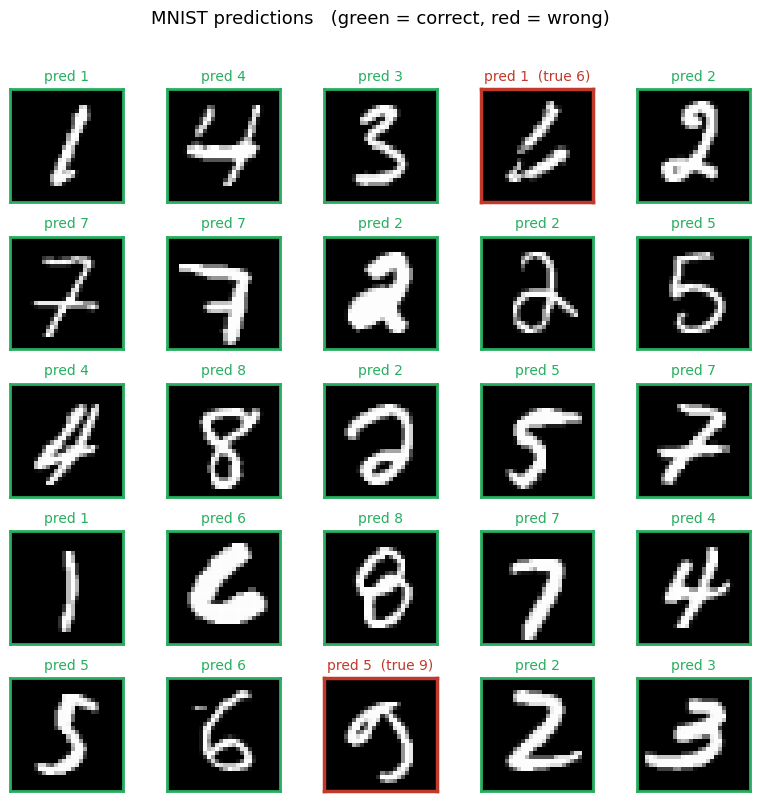


Test accuracy:  0.9909


In [10]:
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

# Sample 23 correct + 2 wrong for the grid
rng_pick = np.random.default_rng(42)
correct_idx = np.where(preds == Yte)[0]
wrong_idx   = np.where(preds != Yte)[0]

n_c, n_w = 23, 2
picks_c = rng_pick.choice(correct_idx, size=n_c, replace=False)
picks_w = rng_pick.choice(wrong_idx,   size=min(n_w, len(wrong_idx)), replace=False)
pick = np.concatenate([picks_c, picks_w])
is_wrong = np.array([False]*len(picks_c) + [True]*len(picks_w))
perm = rng_pick.permutation(len(pick))
pick, is_wrong = pick[perm], is_wrong[perm]

fig, axes = plt.subplots(5, 5, figsize=(8, 8), facecolor="white")
for ax, idx, wrong in zip(axes.flat, pick, is_wrong):
    ax.imshow(Xte[idx].squeeze(), cmap="gray")
    true_label = int(Yte[idx])
    pred_label = int(preds[idx])
    if wrong:
        ax.set_title(f"pred {pred_label}  (true {true_label})", fontsize=10, color="#c0392b")
        for sp in ax.spines.values():
            sp.set_edgecolor("#c0392b"); sp.set_linewidth(2.5)
    else:
        ax.set_title(f"pred {pred_label}", fontsize=10, color="#27ae60")
        for sp in ax.spines.values():
            sp.set_edgecolor("#27ae60"); sp.set_linewidth(2.0)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("MNIST predictions   (green = correct, red = wrong)", fontsize=13, y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()
print(f"\nTest accuracy:  {test_acc:.4f}")


### Core Concept Cheat Sheet: PyTorch ↔ Flax NNX

| Concept | PyTorch | Flax NNX |
|---------|---------|----------|
| Module definition | `class M(nn.Module)` | `class M(nnx.Module)` |
| Parameter declaration | `nn.Parameter(tensor)` | `nnx.Param(jax_array)` |
| Layer | `nn.Linear(in, out)` | `nnx.Linear(in, out, rngs=rngs)` |
| Forward | `def forward(self, x)` | `def __call__(self, x)` |
| Construct model | `model = M()` | `model = M(rngs=nnx.Rngs(0))` |
| Get params | `model.parameters()` | `nnx.state(model, nnx.Param)` |
| Backward | `loss.backward()` | `nnx.value_and_grad(loss_fn)(model)` |
| Update | `optimizer.step()` | `optimizer.update(grads)` |
| JIT | `torch.compile(model)` | `@nnx.jit` |
| Save | `torch.save(state_dict)` | `nnx.split(model)` → Orbax |

---

## Part 4 — Bonus: LoRA Fine-Tuning with NNX

### What is LoRA?

- **A popular technique for fine-tuning large models**
  - Standard fine-tuning trains all params — slow and memory-hungry
  - LoRA freezes the original weights and trains two small low-rank matrices instead
- **Math:** instead of $y = Wx$, use $y = Wx + BAx$
  - $A$, $B$ are low-rank — trainable parameters drop to ~1%

### Why NNX Fits This Naturally

- Modules are mutable → swap an attribute directly, no need to rebuild
  - `model.linear = LoraLinear(model.linear, rank=4)` — one line
- Give A, B their own tag: `class LoraParam(nnx.Variable)`
- `wrt=LoraParam` trains only the new tag — original weights freeze automatically

> The same maneuver in PyTorch usually takes a lot of boilerplate.


In [11]:
class LoraParam(nnx.Variable):
    """Trainable, but separable from the base nnx.Param."""


class LoraLinear(nnx.Module):
    def __init__(self, base: nnx.Linear, rank: int, *, rngs):
        self.base = base                       # frozen
        din, dout = base.in_features, base.out_features
        self.A = LoraParam(jax.random.normal(rngs.params(), (din, rank)) * 0.01)
        self.B = LoraParam(jnp.zeros((rank, dout)))

    def __call__(self, x):
        return self.base(x) + (x @ self.A[...]) @ self.B[...]


# Surgery — swap one attribute on the live model
base_model = MyModel(4, 2, rngs=nnx.Rngs(0))
base_model.linear = LoraLinear(base_model.linear, rank=2, rngs=nnx.Rngs(1))

y = base_model(jnp.ones((1, 4)))
print("LoRA-wrapped model output:", y)
print(f"\nLoraParam A shape: {base_model.linear.A.shape}")
print(f"LoraParam B shape: {base_model.linear.B.shape}")
print(f"Trainable LoRA params: {base_model.linear.A[...].size + base_model.linear.B[...].size}")
print(f"Frozen base params:    {base_model.linear.base.kernel[...].size + base_model.linear.base.bias[...].size}")

LoRA-wrapped model output: [[ 0.05565438 -1.3324687 ]]

LoraParam A shape: (4, 2)
LoraParam B shape: (2, 2)
Trainable LoRA params: 12
Frozen base params:    10


---

## Resources & References

- **Flax docs** — https://flax.readthedocs.io/
- **NNX Basics** — https://flax.readthedocs.io/en/stable/nnx_basics.html
- **MNIST Tutorial** — https://flax.readthedocs.io/en/stable/mnist_tutorial.html
- **Why NNX?** — https://flax.readthedocs.io/en/stable/why.html
- **GitHub** — https://github.com/google/flax

Thank you